In [1]:
import corner
import matplotlib.pyplot as pl
import numpy as np
import os
from astropy.io import fits 

indir = '/home/ubuntu/work/lcretrieval/results/HD209458b/results-260508-joint-pix/'
infile  = os.path.join(indir, 'HD209458b.fits')

with fits.open(infile) as hdul:
    header = hdul['MCMC'].header
    data = hdul['MCMC'].data
    postsamples = np.column_stack([data[name] for name in data.dtype.names])
    pnames = [name for name in data.dtype.names]


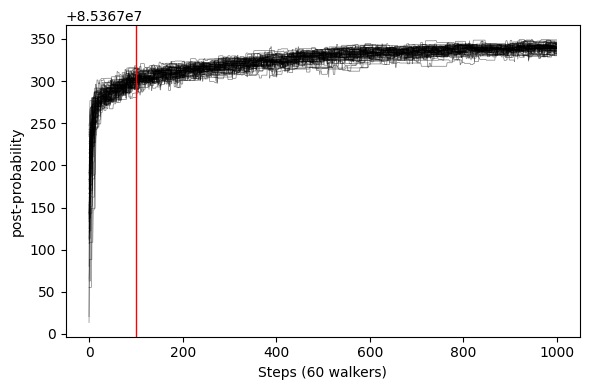

In [ ]:
infile = indir + 'lnprob.txt'
burnin = 100

lnprobs = np.loadtxt(infile)
maxlike_id = lnprobs.flatten().argmax()
maxlike_params = postsamples[maxlike_id] 

fig, ax = pl.subplots(1,1,figsize=(6,4))
ax.plot(lnprobs, c='k', lw=0.5, alpha=0.5)
ax.axvline(burnin, c='r', lw=1)
ax.set_xlabel(f'Steps ({lnprobs.shape[1]} walkers)')
ax.set_ylabel('post-probability')
fig.tight_layout()

In [4]:
# s = postsamples[np.where(lnprobs.flatten() > 84827740)[0]]
s = postsamples[lnprobs.shape[1]*burnin:, :]  
# s = postsamples[60*200:, :] 

fig = corner.corner(
    s, labels=pnames,
    truths=maxlike_params, 
    range=0.999*np.ones(s.shape[1]),
    levels=[0.3935, 0.8647, 0.9889],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True, title_fmt='.4g',
    plot_datapoints=False, plot_density=True,
)
fig.savefig('corner_plot-new.pdf')
pl.close(fig)


In [3]:
print("Max-Likelihood parameters:")
for n in pnames:
    print(f"{n}: {maxlike_params[pnames.index(n)]:.6f}") 

Max-Likelihood parameters:
rho: 1.051685
p: 3.524749
b: 0.503780
tc_00: 2459890.226458
teff: 6000.040578
logg: 4.487692
metal: -0.263993
sigma_m_00: 2.309670
sigma_m_01: 1.783741
sigma_m_02: 1.328031
sigma_m_03: 1.064089
sigma_m_04: 1.017694
mp: 0.709183
ref_p: -2.090321
cloud_p: -6.539087
kir: -3.725695
gamma: -0.497910
tint: 135.352494
ab: 0.445231
m2h: -0.819323
c2o: 0.160391
cloud_f: 0.609950


In [14]:

file1 = "../results/HD209458b/results-260510-benchmark-r100-isothermal/HD209458b.fits"
file2 = "../results/HD209458b/results-260510-benchmark-pix-isothermal/HD209458b.fits"

with fits.open(file1) as hdul:
    header = hdul['MCMC'].header
    data = hdul['MCMC'].data
    postsamples1 = np.column_stack([data[name] for name in data.dtype.names])
    pnames = [name for name in data.dtype.names]

with fits.open(file2) as hdul: 
    data = hdul['MCMC'].data
    postsamples2 = np.column_stack([data[name] for name in data.dtype.names])
    
burnin = 50
nwalkers = 60
true_values = np.array([
    1.00, 3.52474859, 0.50, 2459890.20, 
    6000, 4.5, 0.0, 1.5, 1.5, 
    0.8, -3, -5, 1500, 0.0, 0.5, 0.5
])

s1 = postsamples1[nwalkers*burnin:, :] 
s2 = postsamples2[nwalkers*burnin:, :]

fig = corner.corner(
    s1, labels=pnames,
    # truths=true_values, 
    # range=0.999*np.ones(s2.shape[1]),
    levels=[0.3935, 0.8647, 0.9889],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=False, title_fmt='.4g',
    plot_datapoints=False, plot_density=True,
    # contour_kwargs=dict(linestyles=[':','-.', '-'], lw=1.5),
    color='C1', 
)

fig = corner.corner(
    s2, labels=None,
    truths=true_values, 
    # range=0.999*np.ones(s1.shape[1]),
    levels=[0.3935, 0.8647, 0.9889],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True, title_fmt='.4g',
    plot_datapoints=False, plot_density=True,
    # contour_kwargs=dict(linestyles=[':','-.', '-'], lw=1.5),
    fig=fig, color='#5e3c99', 
)

fig.savefig('corner_plot-comb.pdf')
pl.close(fig)